In [1]:
import pandas as pd
customers = pd.read_csv('mallcustomers.csv')

In [2]:
customers.head()

,CustomerID,Gender,Age,Income,SpendingScore
0,1,Male,19,15000,39
1,2,Male,21,15000,81
2,3,Female,20,16000,6
3,4,Female,23,16000,77
4,5,Female,31,17000,40


In [3]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     200 non-null    int64 
 1   Gender         200 non-null    object
 2   Age            200 non-null    int64 
 3   Income         200 non-null    int64 
 4   SpendingScore  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
customers.describe(include = "all")

,CustomerID,Gender,Age,Income,SpendingScore
count,200.000000,200,200.000000,200.000000,200.000000
unique,NaN,2,NaN,NaN,NaN
top,NaN,Female,NaN,NaN,NaN
freq,NaN,112,NaN,NaN,NaN
mean,100.500000,NaN,38.850000,60560.000000,50.200000
std,57.879185,NaN,13.969007,26264.721165,25.823522
min,1.000000,NaN,18.000000,15000.000000,1.000000
25%,50.750000,NaN,28.750000,41500.000000,34.750000
50%,100.500000,NaN,36.000000,61500.000000,50.000000
75%,150.250000,NaN,49.000000,78000.000000,73.000000


In [5]:
from matplotlib import pyplot as plt
import seaborn as sns
sns.set_theme()

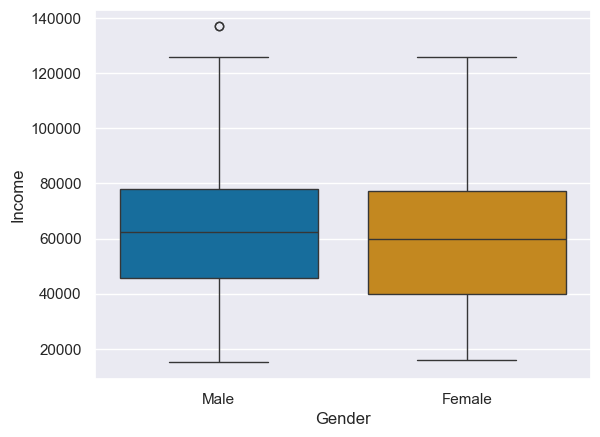

In [6]:
ax = sns.boxplot(data=customers, x='Gender', y='Income', palette='colorblind', hue='Gender')

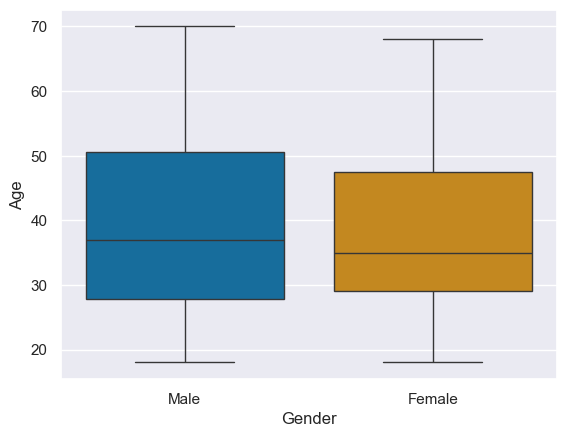

In [7]:
ax = sns.boxplot(data=customers, x='Gender', y='Age', palette='colorblind', hue='Gender')

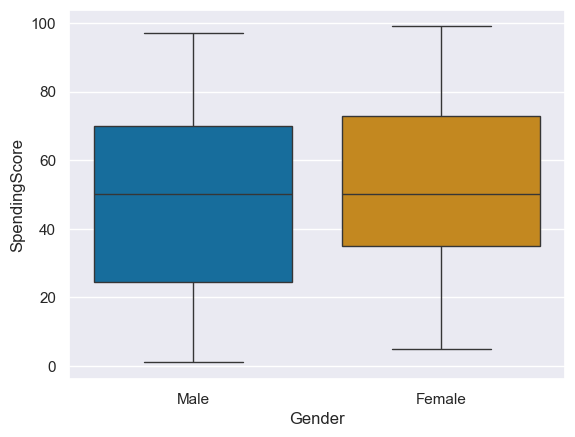

In [8]:
ax = sns.boxplot(data=customers, x='Gender', y='SpendingScore', palette='colorblind', hue='Gender')

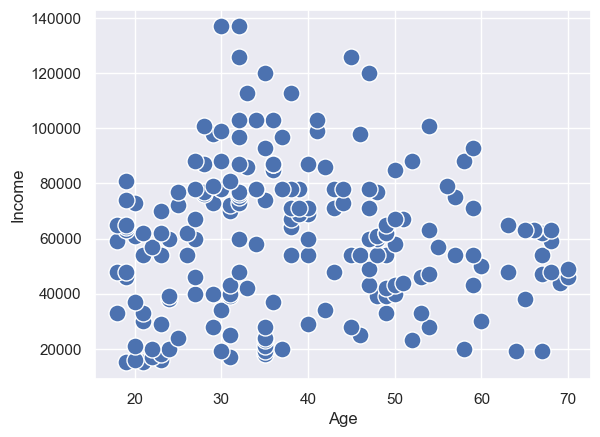

In [9]:
ax = sns.scatterplot(data=customers, x='Age', y='Income', s=150)

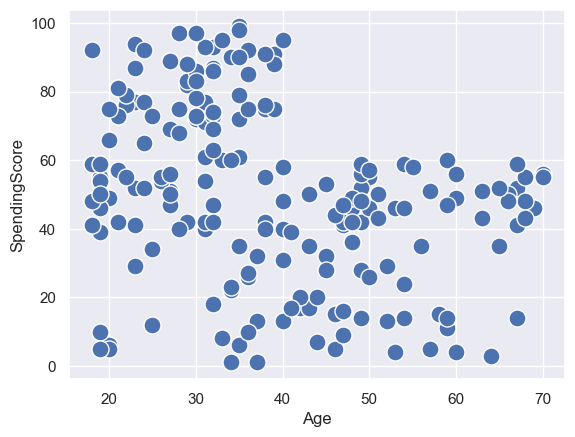

In [10]:
ax = sns.scatterplot(data=customers, x='Age', y='SpendingScore', s=150)

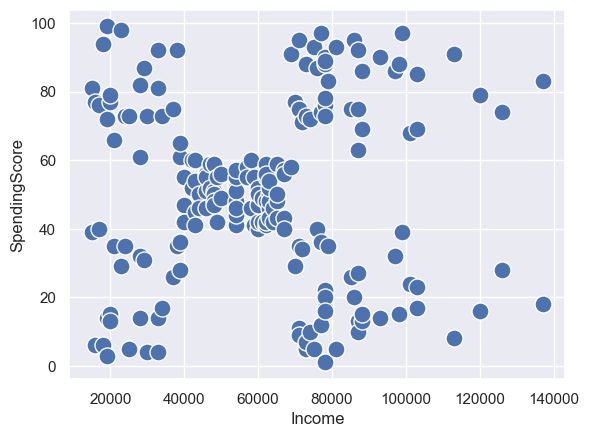

In [11]:
ax = sns.scatterplot(data=customers, x='Income', y='SpendingScore', s=150)

In [13]:
customers[['Income', 'SpendingScore']].describe().round(2)

,Income,SpendingScore
count,200.00,200.00
mean,60560.00,50.20
std,26264.72,25.82
min,15000.00,1.00
25%,41500.00,34.75
50%,61500.00,50.00
75%,78000.00,73.00
max,137000.00,99.00


In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [19]:
customers_scaled = scaler.fit_transform(customers[['Income', 'SpendingScore']])

In [22]:
customers_scaled = pd.DataFrame(customers_scaled, columns=['Income', 'SpendingScore'])
customers_scaled.describe().round(2)

,Income,SpendingScore
count,200.00,200.00
mean,-0.00,-0.00
std,1.00,1.00
min,-1.74,-1.91
25%,-0.73,-0.60
50%,0.04,-0.01
75%,0.67,0.89
max,2.92,1.89


In [26]:
from sklearn.cluster import KMeans
km = KMeans(n_clusters=3, n_init=25, random_state=1234)

In [28]:
km.fit(customers_scaled)

,n_clusters,3
,init,'k-means++'
,n_init,25
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,1234
,copy_x,True
,algorithm,'lloyd'


In [31]:
km.labels_

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1], dtype=int32)

In [33]:
km.inertia_

157.7040081503595